<a href="https://colab.research.google.com/github/mayankkumarlinghe-jpg/summertraining/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Phase 0 — Library Imports & Configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

In [ ]:
#Loading Dataset
df = pd.read_csv("NetFlix.csv")

In [ ]:
#inspecting the given data
#rows and columns
df.shape

(7787, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   int64 
 10  genres        7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(2), object(10)
memory usage: 730.2+ KB


In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


In [ ]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
7782,s995,TV Show,Blown Away,NaN,NaN,Canada,12-Jul-19,2019,TV-14,1,"International TV Shows, Reality TV",Ten master artists turn up the heat in glassbl...
7783,s996,TV Show,Blue Exorcist,NaN,"Nobuhiko Okamoto, Jun Fukuyama, Kana Hanazawa,...",Japan,1-Sep-20,2017,TV-MA,2,"Anime Series, International TV Shows",Determined to throw off the curse of being Sat...
7784,s997,Movie,Blue Is the Warmest Color,Abdellatif Kechiche,"Léa Seydoux, Adèle Exarchopoulos, Salim Kechio...","France, Belgium, Spain",26-Aug-16,2013,NC-17,180,"Dramas, Independent Movies, International Movies","Determined to fall in love, 15-year-old Adele ..."
7785,s998,Movie,Blue Jasmine,Woody Allen,"Cate Blanchett, Sally Hawkins, Alec Baldwin, L...",United States,8-Mar-19,2013,PG-13,98,"Comedies, Dramas, Independent Movies",The high life leads to high anxiety for a fash...
7786,s999,Movie,Blue Jay,Alex Lehmann,"Sarah Paulson, Mark Duplass, Clu Gulager",United States,6-Dec-16,2016,TV-MA,81,"Dramas, Independent Movies, Romantic Movies",Two former high school sweethearts unexpectedl...


In [ ]:
#analysing random sample
df.sample(10, random_state=42)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
7324,s7591,Movie,Whindersson Nunes: Adult,Diego Pignataro,Whindersson Nunes,Brazil,15-Aug-19,2019,TV-MA,69,Stand-Up Comedy,Brazilian YouTube sensation Whindersson Nunes ...
4694,s5223,TV Show,Rita,NaN,"Mille Dinesen, Carsten Bjørnlund, Lise Baastru...",Denmark,15-Aug-20,2020,TV-MA,5,"International TV Shows, TV Comedies, TV Dramas","Independent, outspoken and adored by her stude..."
1322,s2189,Movie,FirstBorn,Nirpal Bhogal,"Antonia Thomas, Luke Norris, Thea Petrie, Eile...",United Kingdom,31-Mar-17,2016,TV-MA,90,"Horror Movies, International Movies",A young couple fights supernatural foes in an ...
5106,s5595,Movie,Si Doel the Movie 3,Rano Karno,"Rano Karno, Cornelia Agatha, Maudy Koesnaedi, ...",Indonesia,23-May-20,2020,TV-G,93,"Dramas, International Movies, Music & Musicals",Torn between reuniting with one family and lea...
101,s109,TV Show,3Below: Tales of Arcadia,NaN,"Tatiana Maslany, Diego Luna, Nick Offerman, Ni...",United States,12-Jul-19,2019,TV-Y7,2,"Kids' TV, TV Action & Adventure, TV Sci-Fi & F...","After crash-landing on Earth, two royal teen a..."
3653,s4287,Movie,Muran,Rajan Madhav,"Prasanna, Cheran, Haripriya, Nikhita, Suma Bha...",India,1-Oct-18,2011,TV-14,134,"Action & Adventure, International Movies",When jingle composer Nanda's car breaks down o...
3519,s4166,Movie,Mojave,William Monahan,"Garrett Hedlund, Oscar Isaac, Louise Bourgoin,...",United States,26-Jul-18,2015,R,93,"Dramas, Independent Movies, Thrillers",A lethal game of cat and mouse stretches from ...
487,s1437,TV Show,Club Friday To Be Continued - The Promise,NaN,"Jirayu La-ongmanee, Focus Jirakul",NaN,20-Apr-18,2016,TV-MA,1,"International TV Shows, Romantic TV Shows, TV ...",Two young lovers vow to stay friends through t...
6022,s6419,TV Show,The Great British Baking Show: The Beginnings,NaN,"Paul Hollywood, Mary Berry, Mel Giedroyc, Sue ...",NaN,1-Nov-18,2012,TV-PG,1,"British TV Shows, Reality TV",A dozen amateur bakers amiably compete for the...
3274,s3946,Movie,Marlon Wayans: Woke-ish,Marcus Raboy,Marlon Wayans,United States,27-Feb-18,2018,TV-MA,67,Stand-Up Comedy,"Rollicking, outrageous and audacious, Marlon W..."


In [ ]:
#analysing columns and datatypes
df.columns.tolist()
df.info()
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   int64 
 10  genres        7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(2), object(10)
memory usage: 730.2+ KB


In [ ]:
#Summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
release_year,7787.0,2013.932580,8.757395,1925.0,2013.0,2017.0,2018.0,2021.0
duration,7787.0,69.122769,50.950743,1.0,2.0,88.0,106.0,312.0


In [ ]:
#Missing value count
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2389
cast,718
country,507
date_added,10
release_year,0
rating,7
duration,0


In [ ]:
df.isnull().sum() > 0


,0
show_id,False
type,False
title,False
director,True
cast,True
country,True
date_added,True
release_year,False
rating,True
duration,False


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
director,2389
cast,718
country,507
date_added,10
rating,7
title,0
show_id,0
type,0
release_year,0
duration,0


In [ ]:
df.duplicated().sum()

np.int64(0)

<Axes: >

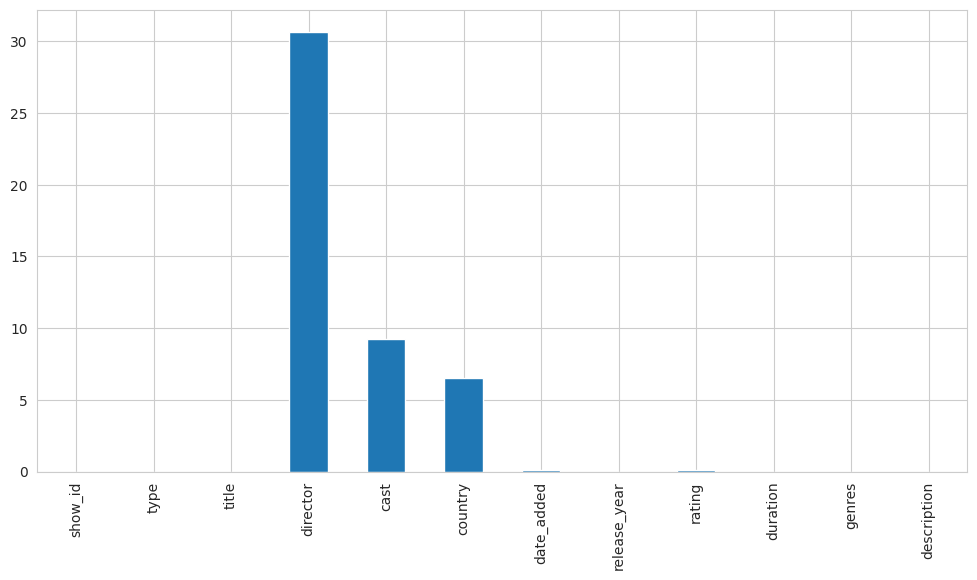

In [ ]:
#  Missing Value Percentages and Visualisation
missing_percentages = (df.isnull().sum() / len(df) * 100).round(2)
missing_percentages.sort_values(ascending=False)
missing_percentages.plot(kind='bar')

In [ ]:
#Duplicate Detection
print(df.duplicated().sum())
data_percentage = (df.duplicated().sum() / len(df) * 100).round(2)
print(data_percentage)
df[df.duplicated(keep=False)]

0
0.0


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description


In [ ]:
# Unique Value Counts
df.nunique()
df.nunique().sort_values()

,0
type,2
rating,14
release_year,73
duration,206
genres,492
country,681
date_added,1565
director,4049
cast,6831
description,7769


In [ ]:
#check invalid data
check_invalid_data = df.apply(lambda x: pd.to_numeric(x, errors='coerce').notna().all())
print(check_invalid_data)

show_id         False
type            False
title           False
director        False
cast            False
country         False
date_added      False
release_year     True
rating          False
duration         True
genres          False
description     False
dtype: bool


In [ ]:
# Data Quality Summary
data_quality_summary = {
    'Missing Values': df.isnull().sum(),
    'Missing Values Percentage': (df.isnull().sum() / len(df) * 100).round(2),
    'Duplicate Rows': df.duplicated().sum(),
    'Duplicate Rows Percentage': (df.duplicated().sum() / len(df) * 100).round(2),
    'Unique Values': df.nunique(),
    'Data Types': df.dtypes
}
data_quality_summary_df = pd.DataFrame(data_quality_summary)
data_quality_summary_df


,Missing Values,Missing Values Percentage,Duplicate Rows,Duplicate Rows Percentage,Unique Values,Data Types
show_id,0,0.00,0,0.0,7787,object
type,0,0.00,0,0.0,2,object
title,0,0.00,0,0.0,7787,object
director,2389,30.68,0,0.0,4049,object
cast,718,9.22,0,0.0,6831,object
country,507,6.51,0,0.0,681,object
date_added,10,0.13,0,0.0,1565,object
release_year,0,0.00,0,0.0,73,int64
rating,7,0.09,0,0.0,14,object
duration,0,0.00,0,0.0,206,int64


In [ ]:
#Creating working copy
df_clean = df.copy()
print(df_clean.shape)
print("df_clean has the same shape as df")


(7787, 12)
df_clean has the same shape as df


In [ ]:
# Remove Duplicates
print(len(df_clean))
df_clean.drop_duplicates(inplace=True)
print(df_clean.shape)
print("df_clean has the same shape as df")

7787
(7787, 12)
df_clean has the same shape as df


In [ ]:
#Handle Missing Values
text_cols = ['director', 'cast', 'country']
df_clean[text_cols] = df_clean[text_cols].fillna('Unknown')

df_clean['date_added'] = pd.to_datetime(df_clean['date_added'], errors='coerce')
mean_date = df_clean['date_added'].mean()
df_clean['date_added'] = df_clean['date_added'].fillna(mean_date)

if df_clean['rating'].dtype in ['int64', 'float64']:
    df_clean['rating'] = df_clean['rating'].fillna(df_clean['rating'].mean())
else:
    most_frequent_rating = df_clean['rating'].mode()[0]
    df_clean['rating'] = df_clean['rating'].fillna(most_frequent_rating)


/tmp/ipykernel_12574/3538668205.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['date_added'] = pd.to_datetime(df_clean['date_added'], errors='coerce')


In [ ]:
#Fix Data Type
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'])
df_clean['release_year'] = df_clean['release_year'].astype(int)
df_clean.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,datetime64[ns]
release_year,int64
rating,object
duration,int64


In [ ]:
#  Removing columns with unknown directors
print(df_clean.shape)
df_clean = df_clean[df_clean['director'] != 'Unknown']
print(df_clean.shape)

(7787, 12)
(5398, 12)


In [ ]:
# Cleaning Summary Comparison
cleaning_summary = {
    'Original Rows': len(df),
    'Cleaned Rows': len(df_clean),
    'Missing Values': df.isnull().sum().sum() - df_clean.isnull().sum().sum(),
    'Duplicate Rows': df.duplicated().sum() - df_clean.duplicated().sum(),
    'Unique Values': df.nunique().sum() - df_clean.nunique().sum()
}
cleaning_summary_df = pd.DataFrame(cleaning_summary, index=['Value'])
cleaning_summary_df


,Original Rows,Cleaned Rows,Missing Values,Duplicate Rows,Unique Values
Value,7787,5398,3631,0,9622


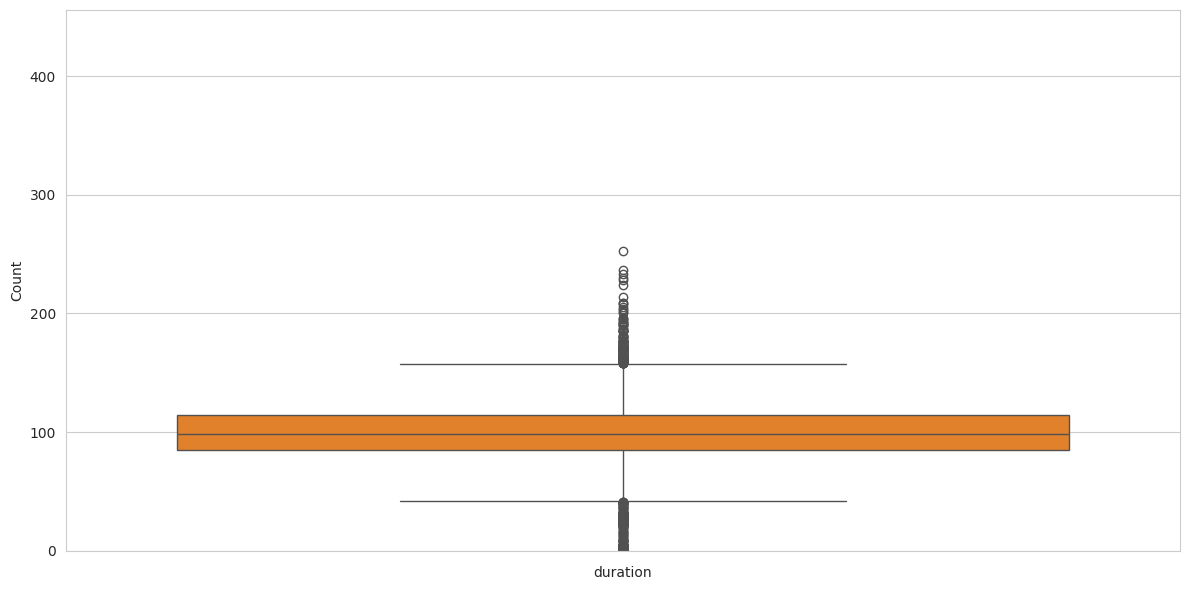

In [ ]:
# Task — Univariate Analysis: duration
df_clean['duration'].describe()
sns.histplot(df_clean['duration'], kde=True)
sns.boxplot(y=df_clean['duration'])
plt.tight_layout()
plt.show()

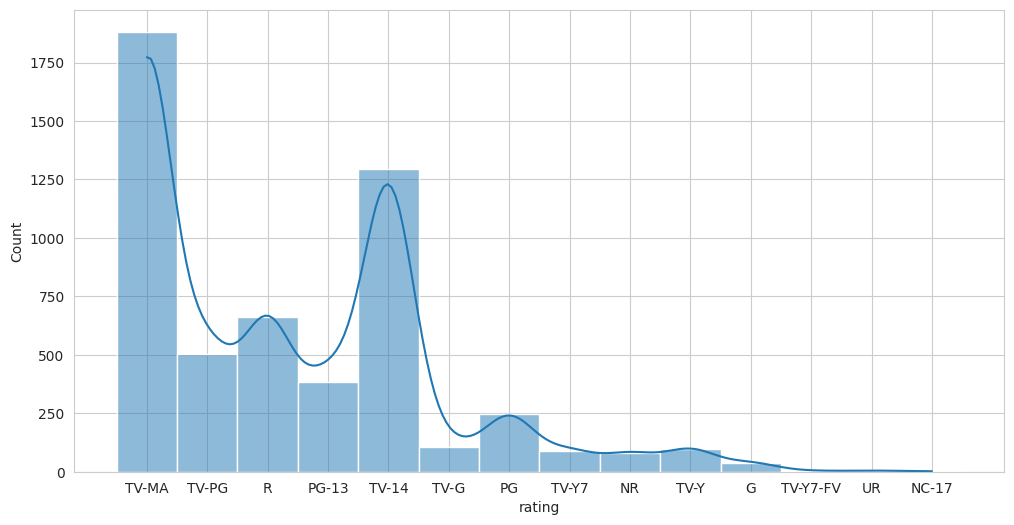

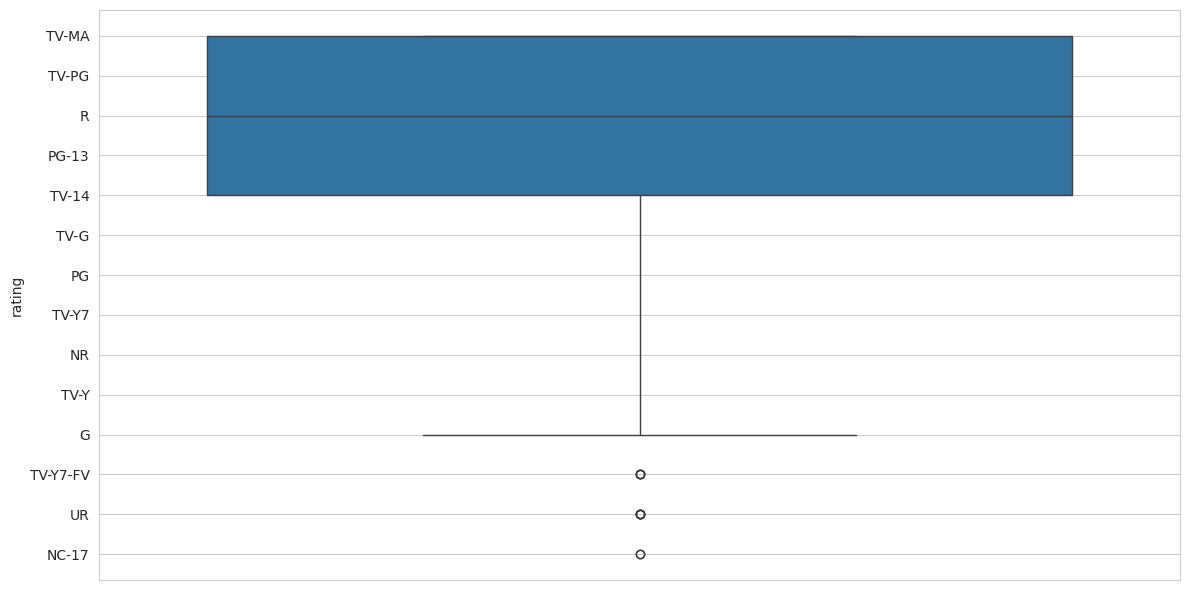

In [ ]:
# Task — Univariate Analysis: rating
df_clean['rating'].describe()
sns.histplot(df_clean['rating'], kde=True)
plt.show()
sns.boxplot(y=df_clean['rating'])
plt.tight_layout()
plt.show()


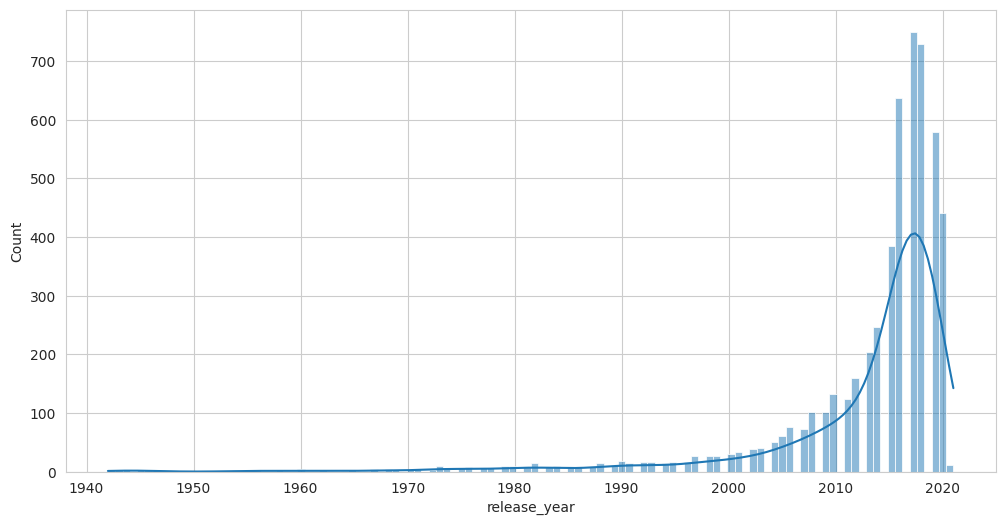

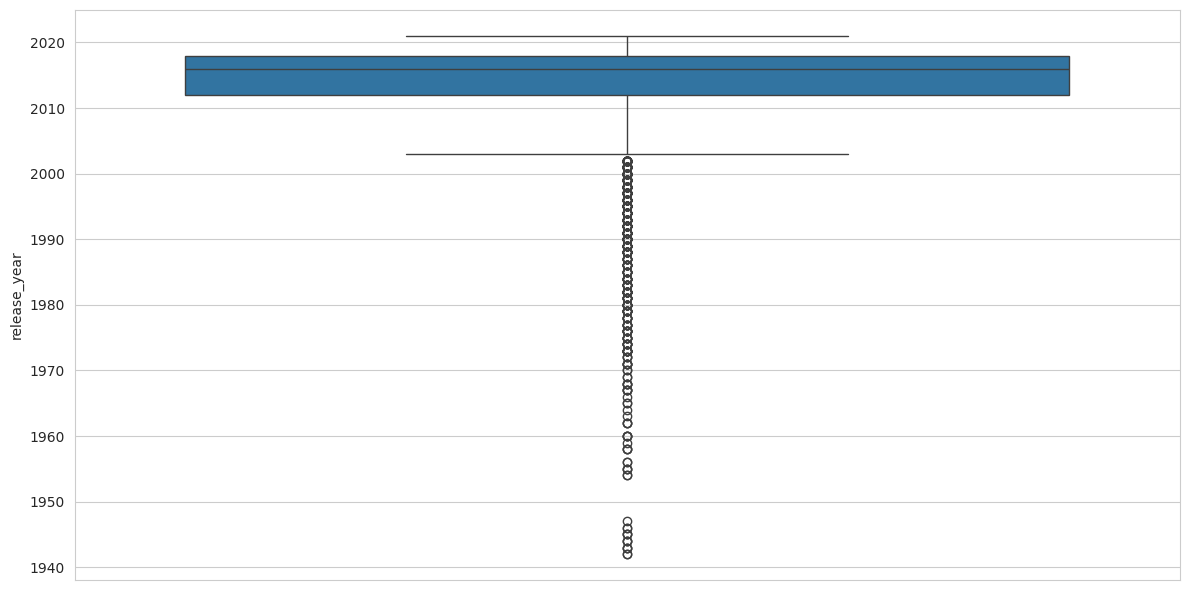

In [ ]:
# Task — Univariate Analysis: release_year
df_clean['release_year'].describe()
sns.histplot(df_clean['release_year'], kde=True)
plt.show()
sns.boxplot(y=df_clean['release_year'])
plt.tight_layout()
plt.show()


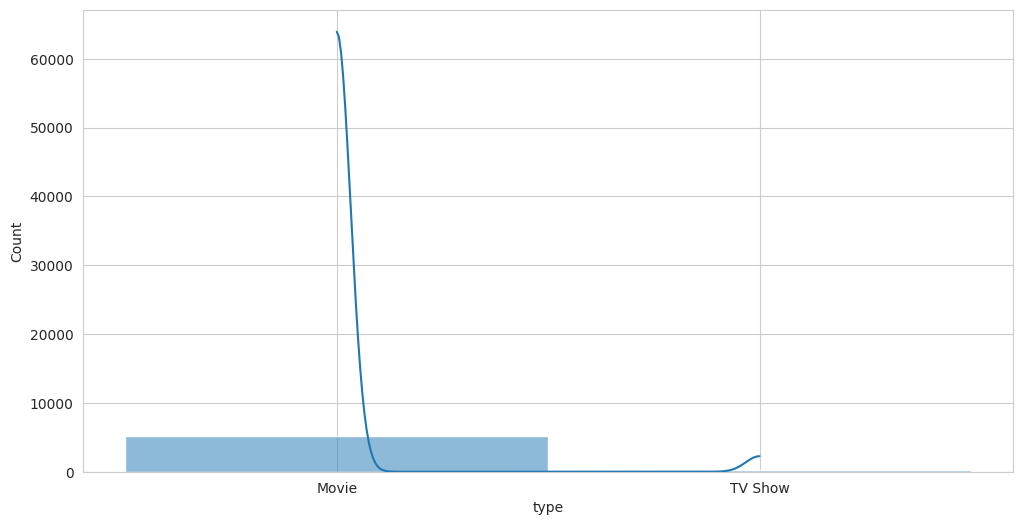

In [ ]:
# Task — Univariate Analysis: type
df_clean['type'].describe()
sns.histplot(df_clean['type'], kde=True)
plt.show()

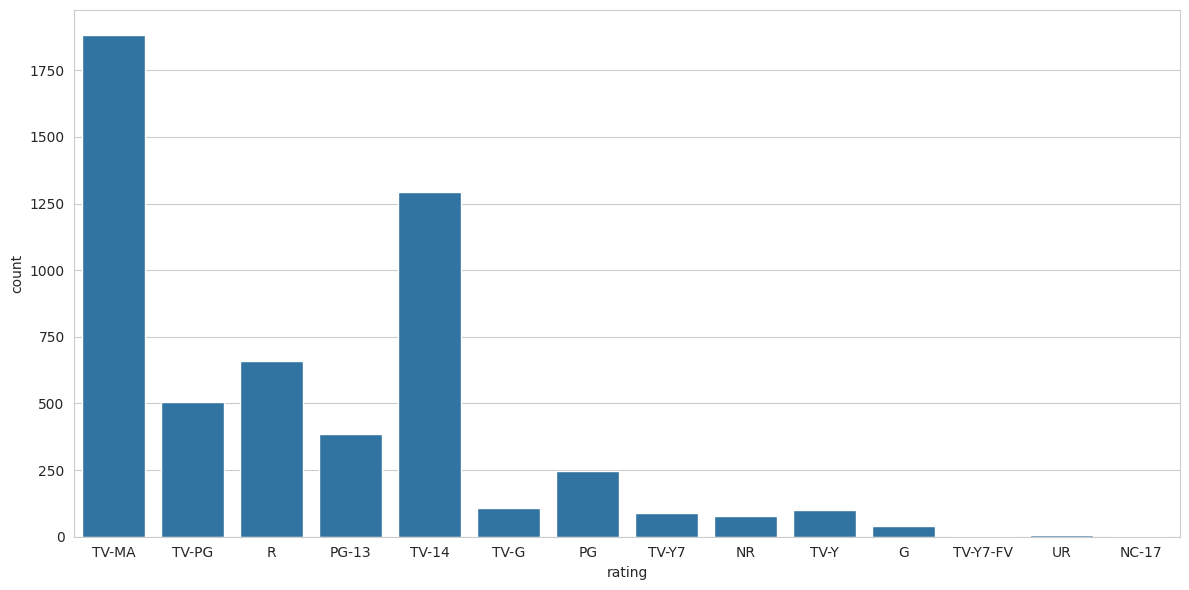

In [ ]:
# Task — Univariate Analysis: rating
df_clean['rating'].value_counts()
sns.countplot(data=df_clean, x='rating')
plt.tight_layout()
plt.show()

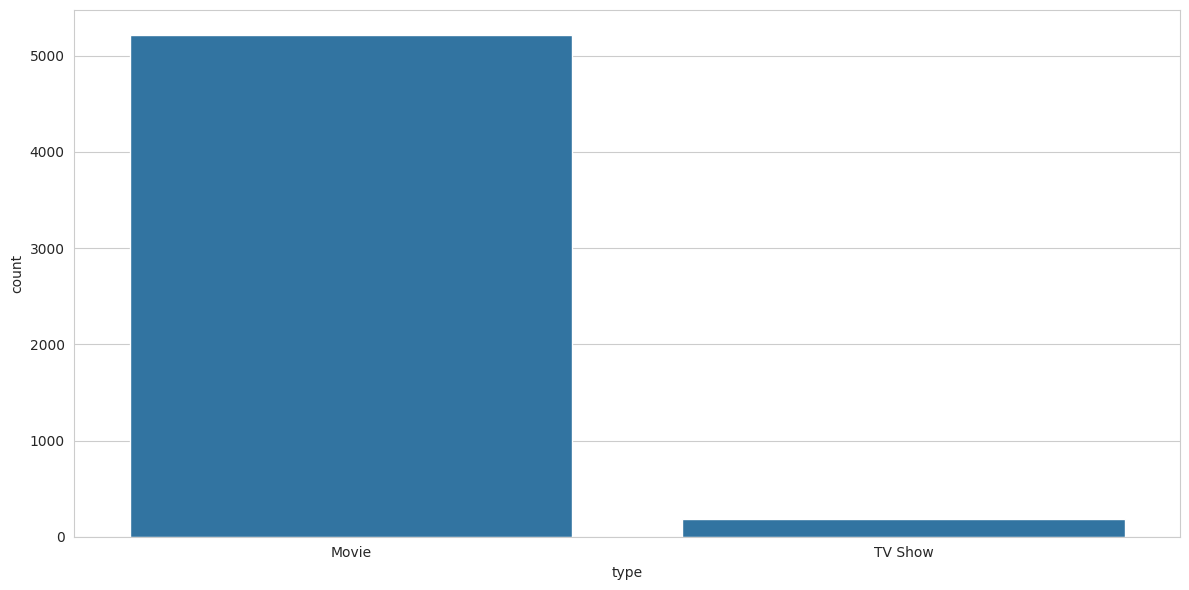

In [ ]:
# Task — Univariate Analysis: type
df_clean['type'].value_counts()
sns.countplot(data=df_clean, x='type')
plt.tight_layout()
plt.show()

Count of Outlier using IQR MEthod 500
Count of Outlier using Z-Score MEthod 148


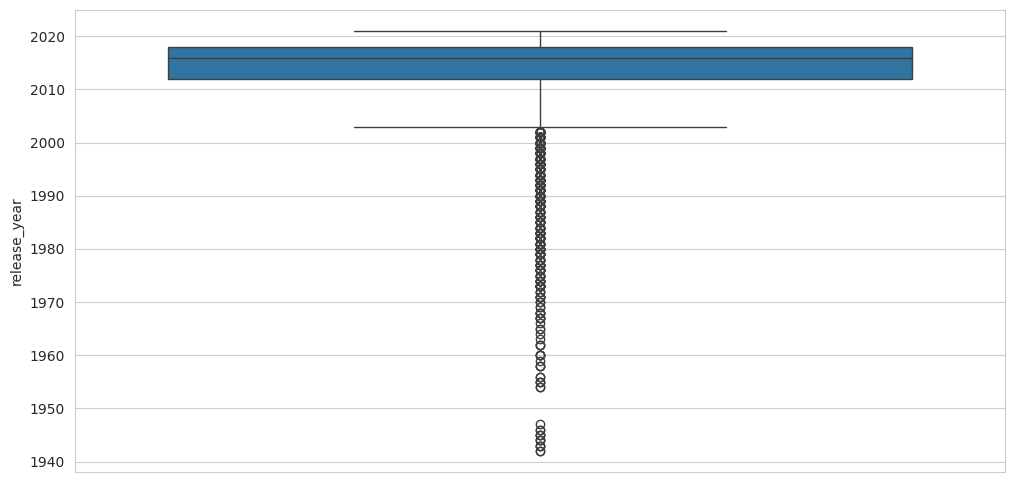

In [ ]:
# Outlier Detection: release_year
sns.boxplot(y=df_clean['release_year'])
IQR = df_clean['release_year'].quantile(0.75) - df_clean['release_year'].quantile(0.25)
lower_fence = df_clean['release_year'].quantile(0.25) - 1.5 * IQR
upper_fence = df_clean['release_year'].quantile(0.75) + 1.5 * IQR
outliers_iqr = df_clean[(df_clean['release_year'] < lower_fence) | (df_clean['release_year'] > upper_fence)]
print("Count of Outlier using IQR MEthod", len(outliers_iqr))
z_scores = stats.zscore(df_clean['release_year'])
outliers_zscore = df_clean[np.abs(z_scores) > 3]
print("Count of Outlier using Z-Score MEthod",len(outliers_zscore))

Count of Outlier using IQR MEthod 469
Count of Outlier using Z-Score MEthod 18


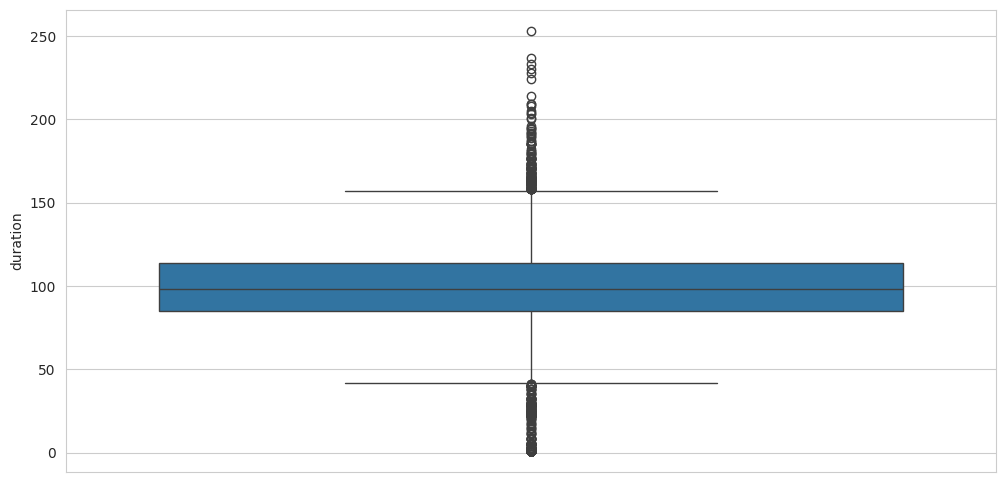

In [ ]:
# Outlier Detection: duration
sns.boxplot(y=df_clean['duration'])
IQR = df_clean['duration'].quantile(0.75) - df_clean['duration'].quantile(0.25)
lower_fence = df_clean['duration'].quantile(0.25) - 1.5 * IQR
upper_fence = df_clean['duration'].quantile(0.75) + 1.5 * IQR
outliers_iqr = df_clean[(df_clean['duration'] < lower_fence) | (df_clean['duration'] > upper_fence)]
print("Count of Outlier using IQR MEthod", len(outliers_iqr))
z_scores = stats.zscore(df_clean['duration'])
outliers_zscore = df_clean[np.abs(z_scores) > 3]
print("Count of Outlier using Z-Score MEthod",len(outliers_zscore))

rating
G            88.076923
NC-17       146.000000
NR           95.443038
PG           98.526316
PG-13       107.774026
R           106.291982
TV-14       107.398456
TV-G         78.481132
TV-MA        91.204570
TV-PG        91.568317
TV-Y         46.080808
TV-Y7        58.112360
TV-Y7-FV     74.500000
UR          106.800000
Name: duration, dtype: float64


/tmp/ipykernel_12574/2647634450.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rating', y='duration', data=df_clean, palette='pastel')


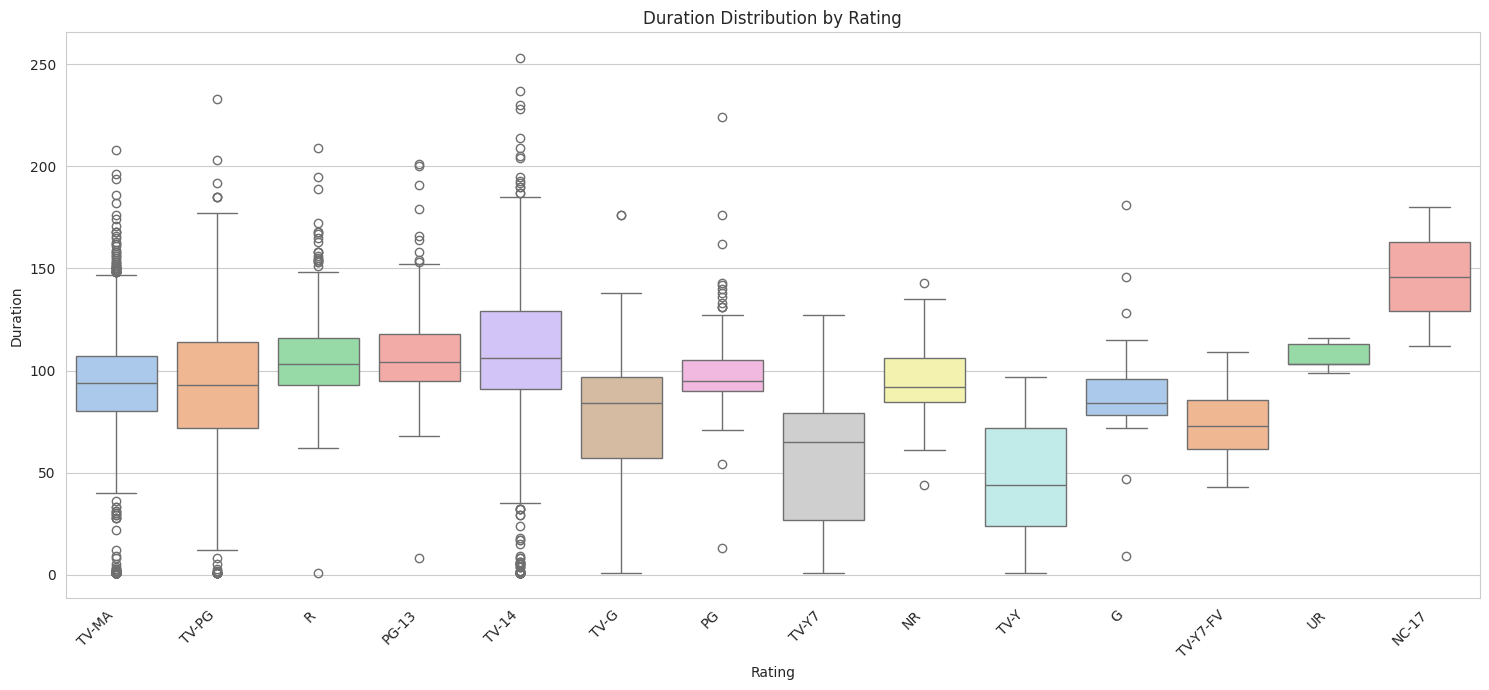

/tmp/ipykernel_12574/2647634450.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rating', y='duration', data=df_clean, errorbar=None, palette='mako') # errorbar=None to show mean directly


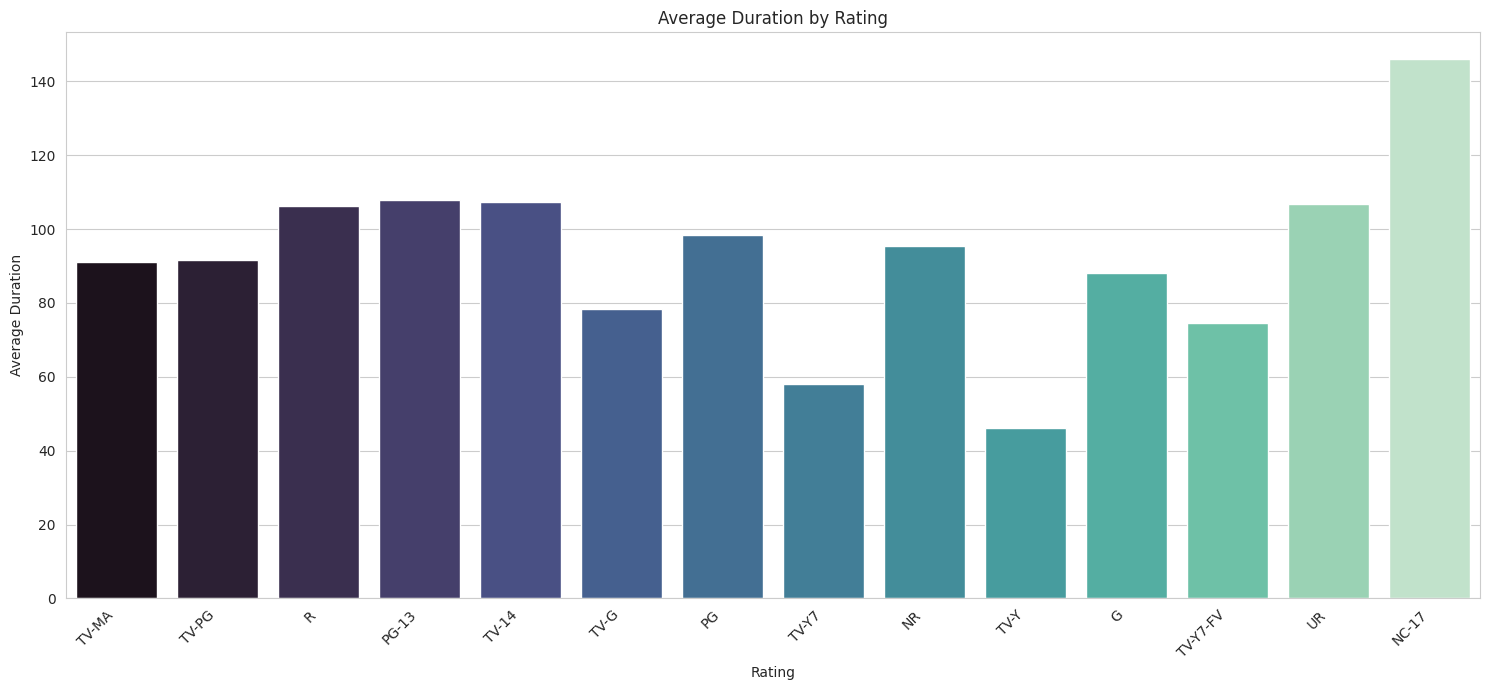

In [ ]:
# duration vs rating

# Display mean duration by rating
print(df_clean.groupby('rating')['duration'].mean())

# Boxplot for duration vs rating
plt.figure(figsize=(15, 7)) # Set a reasonable figure size
sns.boxplot(x='rating', y='duration', data=df_clean, palette='pastel')
plt.title('Duration Distribution by Rating')
plt.xlabel('Rating')
plt.ylabel('Duration')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Barplot for mean duration vs rating
plt.figure(figsize=(15, 7)) # New figure for barplot
sns.barplot(x='rating', y='duration', data=df_clean, errorbar=None, palette='mako') # errorbar=None to show mean directly
plt.title('Average Duration by Rating')
plt.xlabel('Rating')
plt.ylabel('Average Duration')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# pd.crosstab(df_clean['rating'], df_clean['duration']) # This would create a very large table; commenting out unless specifically requested.

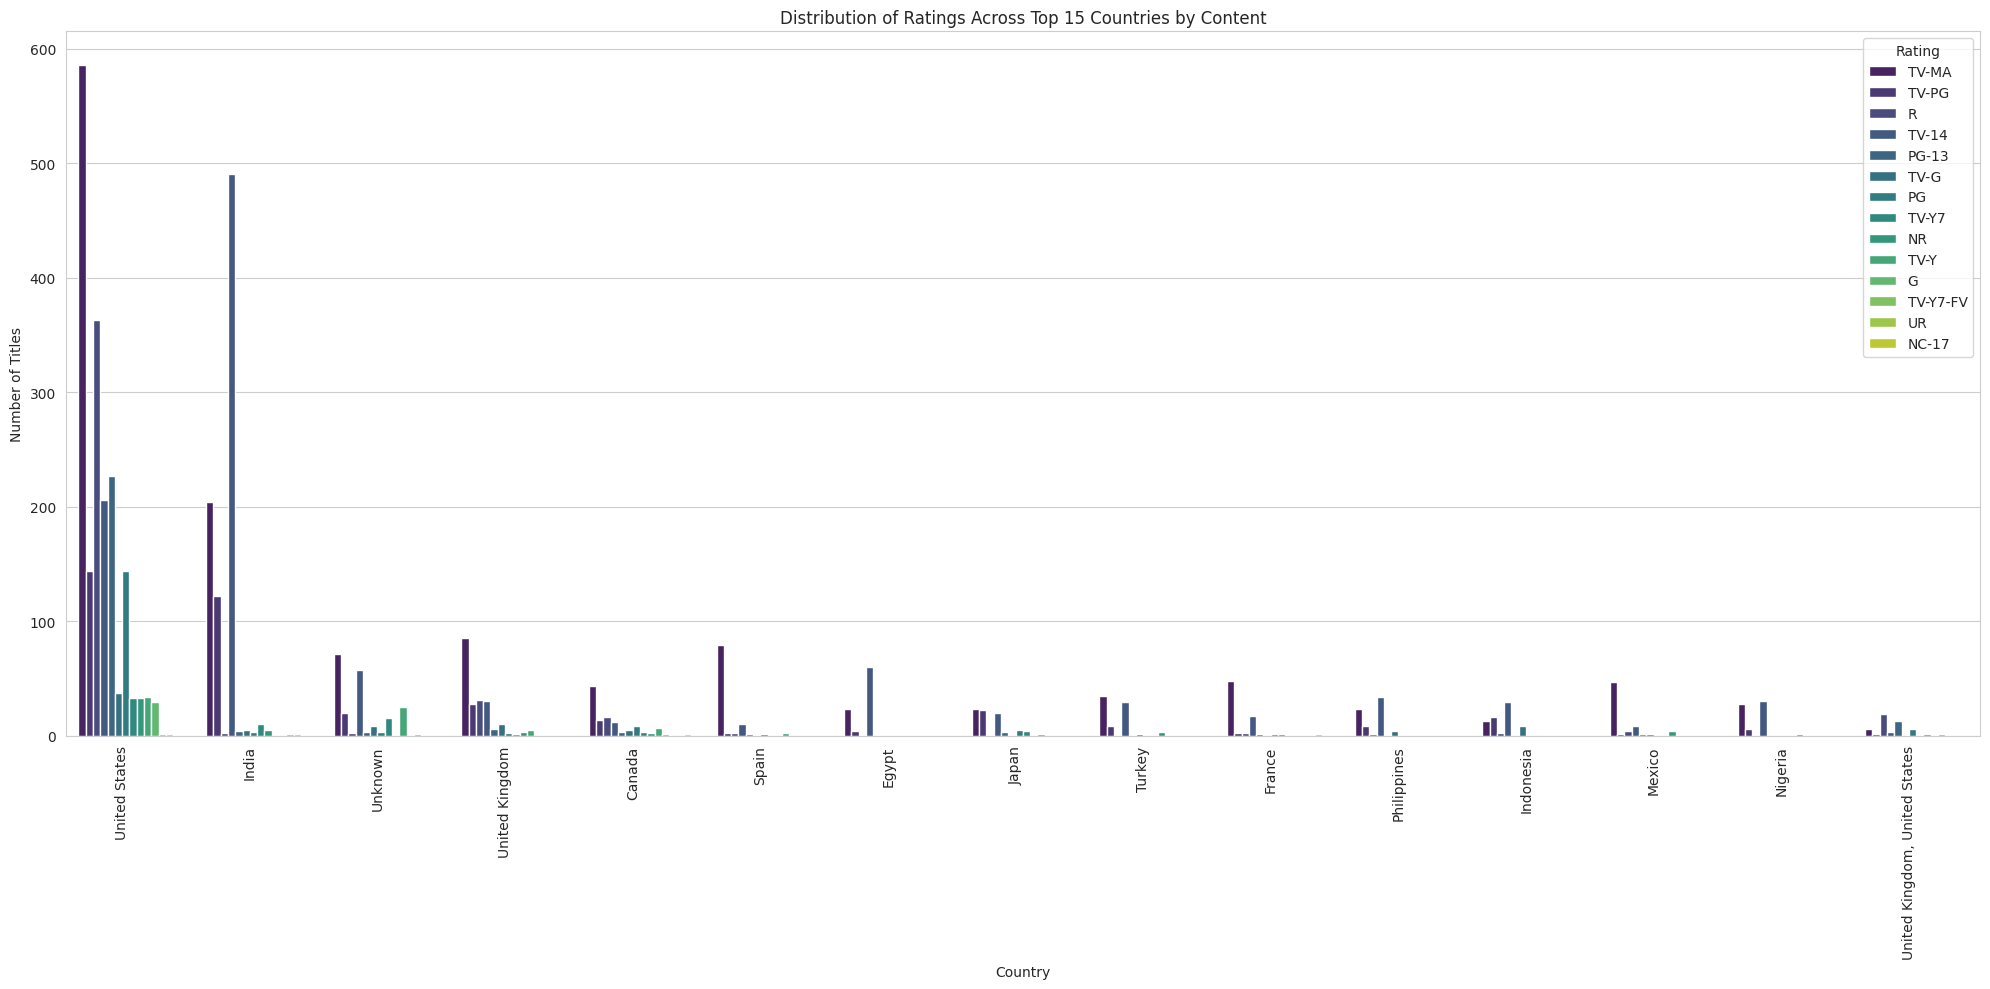

In [ ]:
# top 15 country vs their ratings

plt.figure(figsize=(20, 10)) # Set a reasonable figure size for the plot

# Get top 15 countries by content count
top_15_countries = df_clean['country'].value_counts().head(15).index.tolist()

# Filter data for these top countries
df_top_countries = df_clean[df_clean['country'].isin(top_15_countries)]

# Plotting the distribution of ratings within these top countries
sns.countplot(data=df_top_countries, x='country', hue='rating', order=top_15_countries, palette='viridis')
plt.title('Distribution of Ratings Across Top 15 Countries by Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=90, ha='right')
plt.legend(title='Rating')
plt.tight_layout()
plt.show()

/tmp/ipykernel_12574/3150823347.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.index, y=top_countries.values, palette='viridis')


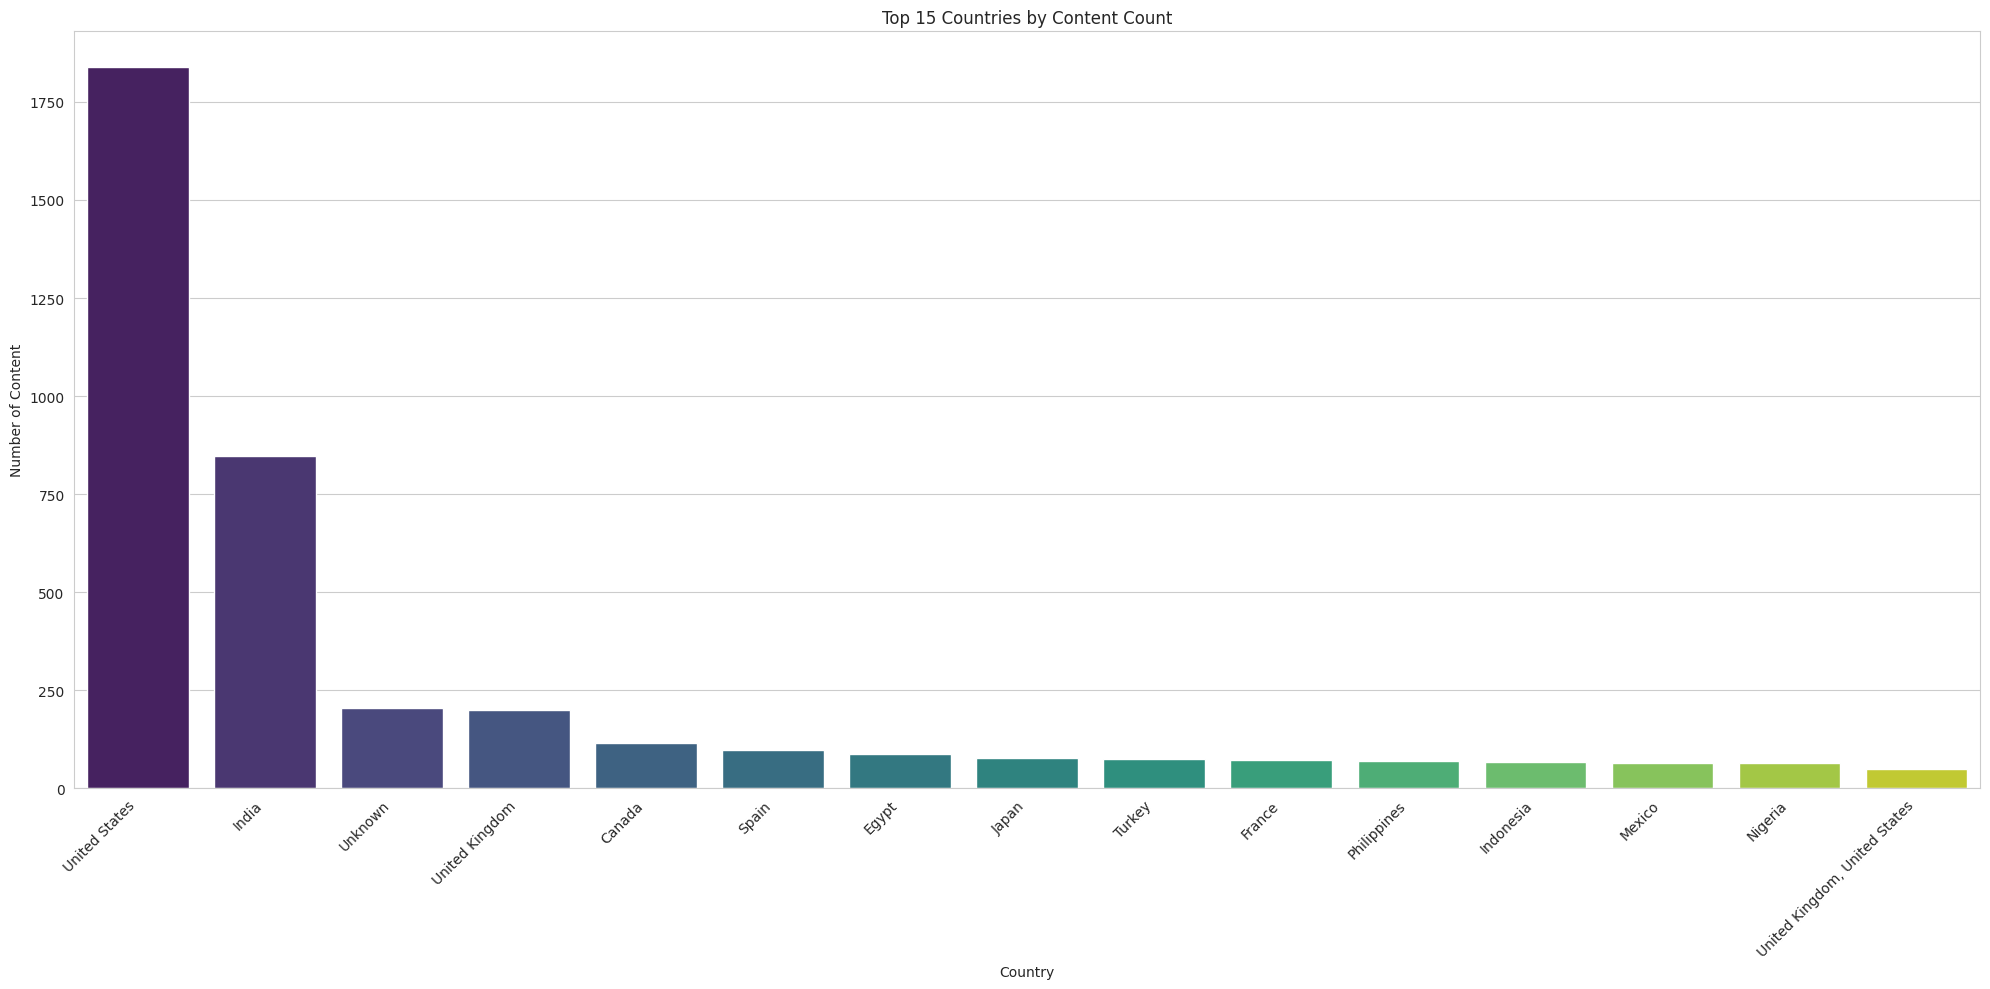

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Task — Univariate Analysis: country
plt.figure(figsize=(20,10))
top_countries = df_clean['country'].value_counts().head(15)
sns.barplot(x=top_countries.index, y=top_countries.values, palette='viridis')
plt.title('Top 15 Countries by Content Count')
plt.xlabel('Country')
plt.ylabel('Number of Content')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

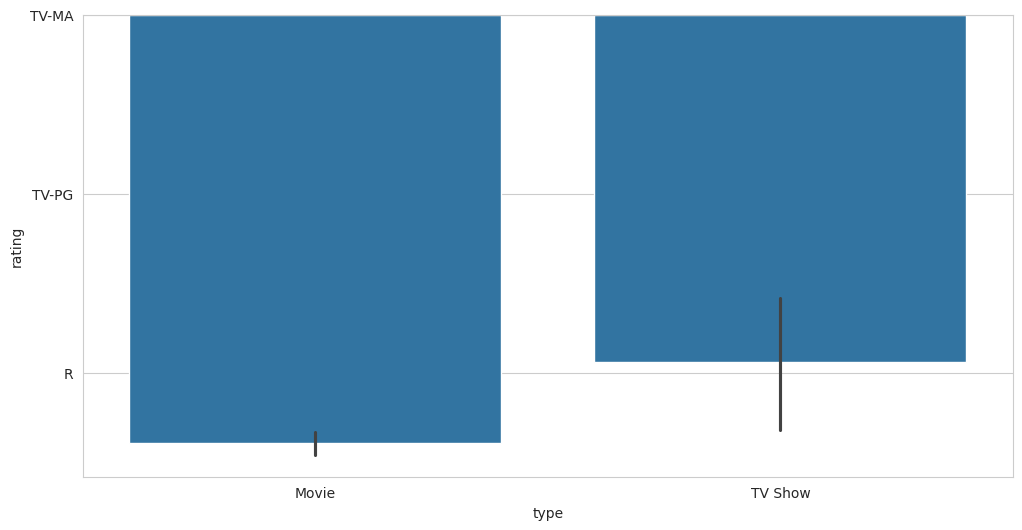

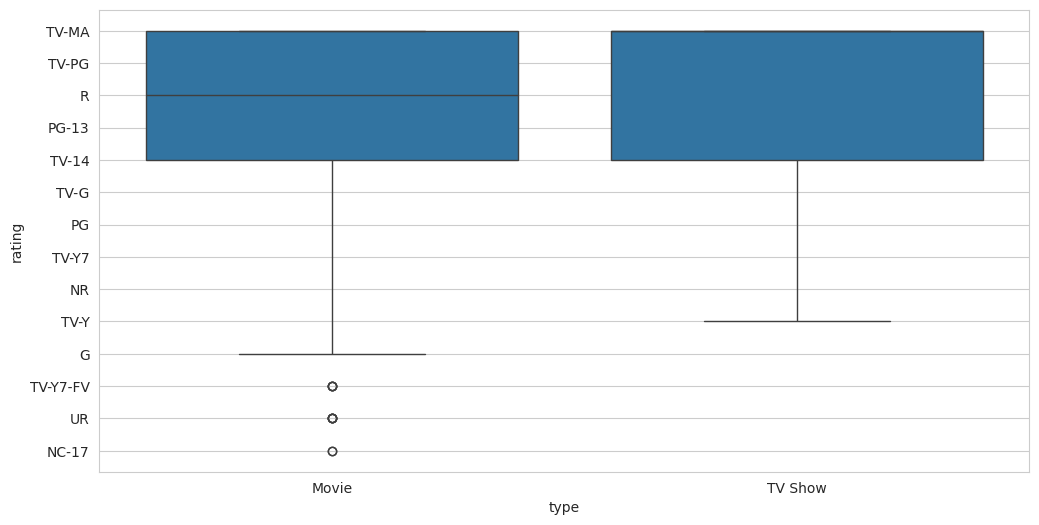

In [ ]:
# type vs rating
df_clean.groupby('type')
sns.barplot(x='type', y='rating', data=df_clean)
plt.show()
sns.boxplot(x='type', y='rating', data=df_clean)
pd.crosstab(df_clean['type'], df_clean['rating'], normalize='index')
plt.show()

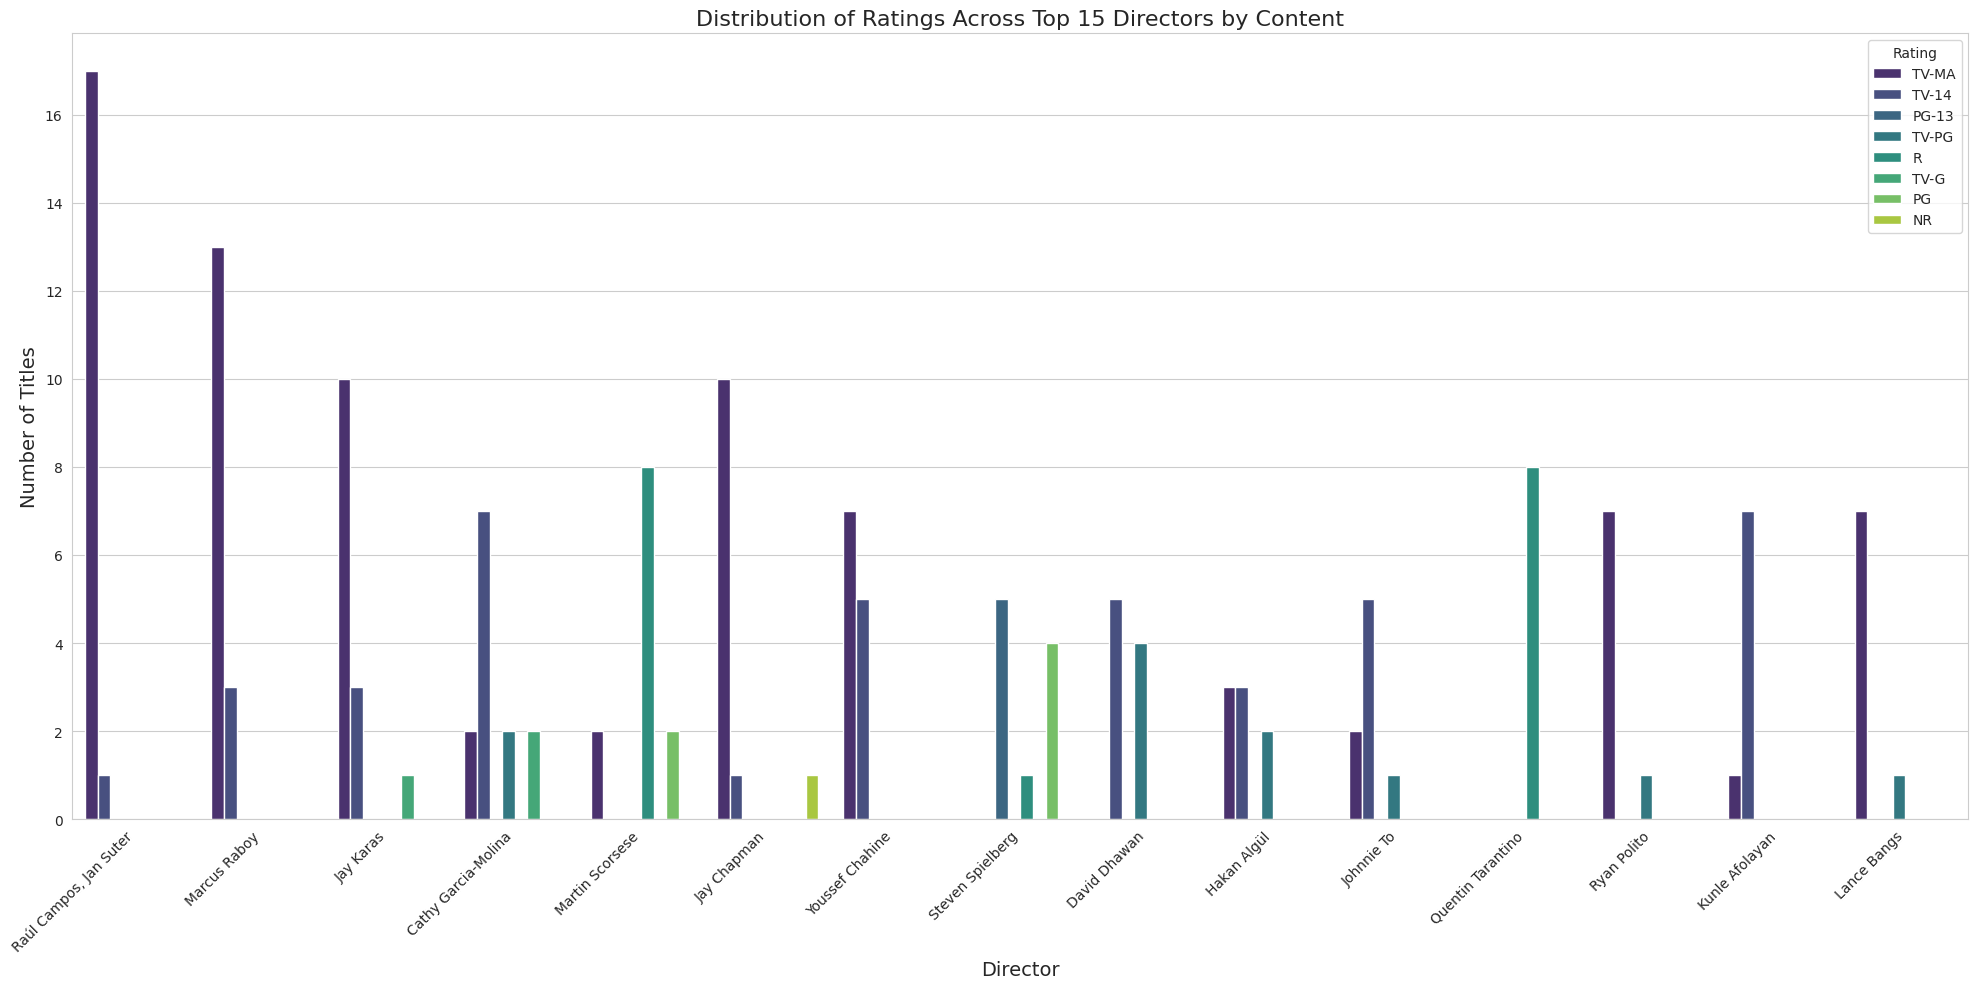

In [ ]:
#director vs rating top 15

# 1. Get top 15 directors by their content count
top_15_directors = (
    df_clean['director'].value_counts().head(15).index.tolist()
)

# 2. Filter the original dataframe for only these top 15 directors
df_top_directors = df_clean[df_clean['director'].isin(top_15_directors)]

# 3. Plot the distribution of ratings for these top directors using a countplot
plt.figure(figsize=(20, 10)) # Set a reasonable figure size
sns.countplot(
    data=df_top_directors,
    x='director',
    hue='rating',
    order=top_15_directors,
    palette='viridis'
)

# 4. Finalize plot aesthetics
plt.title('Distribution of Ratings Across Top 15 Directors by Content', fontsize=16)
plt.xlabel('Director', fontsize=14)
plt.ylabel('Number of Titles', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Rating')
plt.tight_layout()
plt.show()

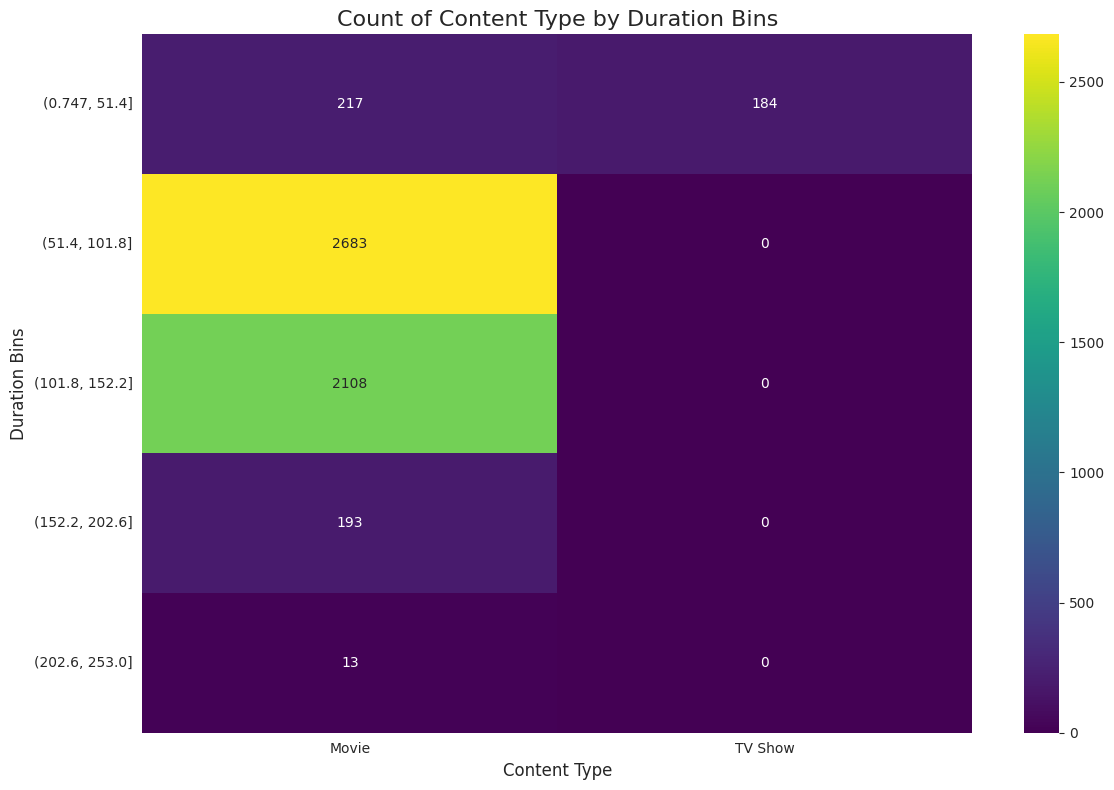

In [ ]:

#  Movie Duration Analysis

# Create 5 bins for duration to make the heatmap readable
bins = pd.cut(df_clean['duration'], bins=5, include_lowest=True)

# 2. Create a cross-tabulation of binned duration and type
heatmap_data = pd.crosstab(bins, df_clean['type'])

# 3. Plotting the heatmap
plt.figure(figsize=(12, 8)) # Adjust figure size for readability
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='viridis')
plt.title('Count of Content Type by Duration Bins', fontsize=16)
plt.xlabel('Content Type', fontsize=12)
plt.ylabel('Duration Bins', fontsize=12)
plt.xticks(rotation=0) # Keep x-axis labels horizontal for readability
plt.yticks(rotation=0) # Keep y-axis labels horizontal for readability
plt.tight_layout()
plt.show()

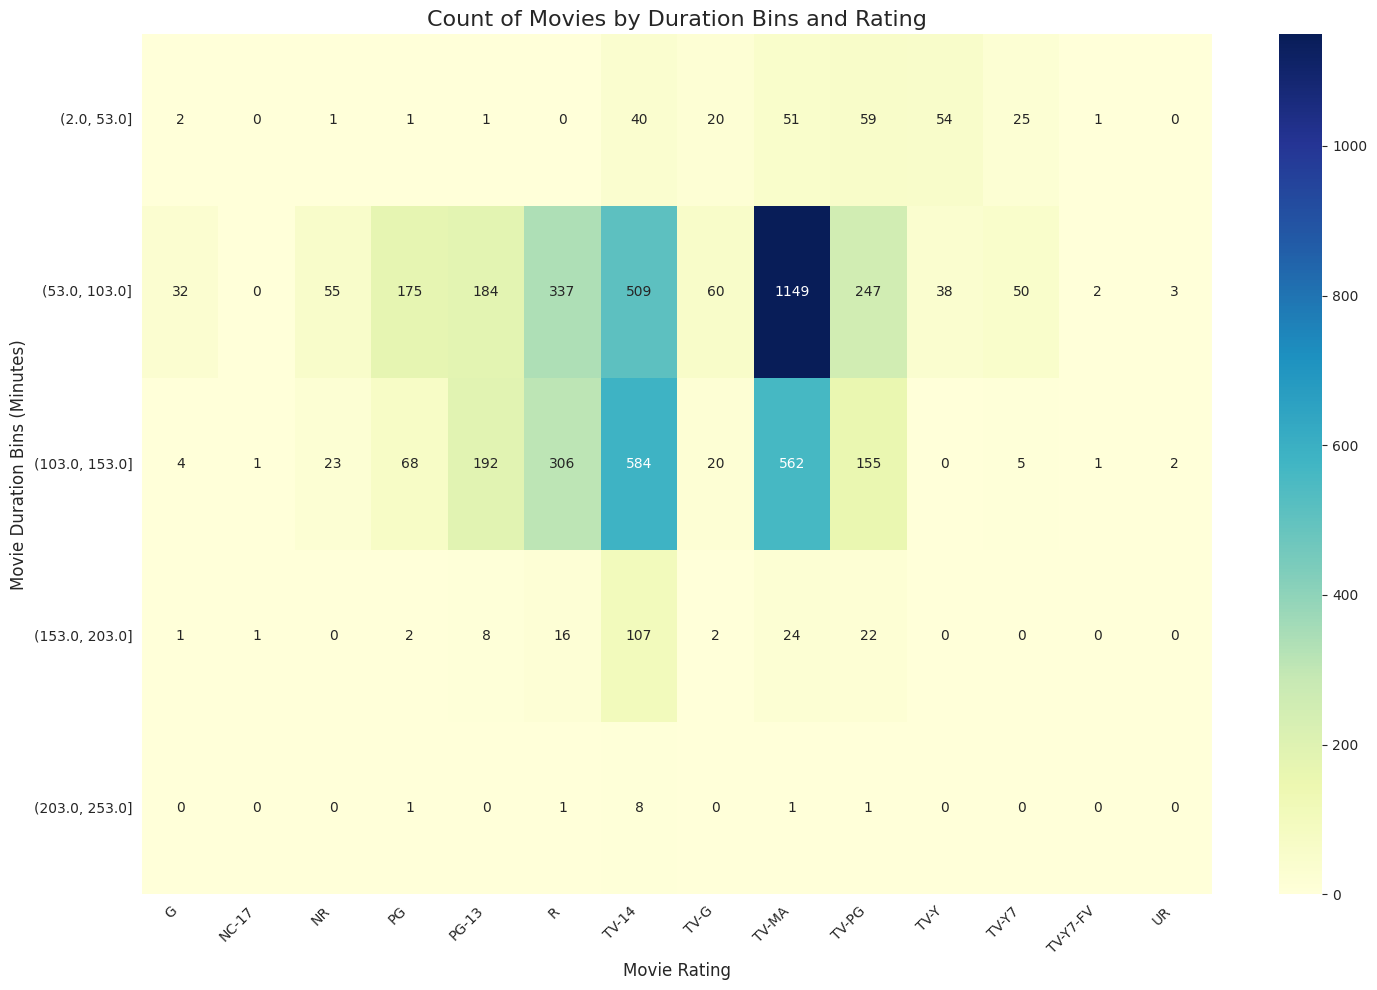

In [ ]:
# Movie Duration and Rating Analysis Heatmap

# Filter for 'Movie' type only
df_movies = df_clean[df_clean['type'] == 'Movie'].copy()

# Create 5 bins for movie duration to make the heatmap readable
# Ensure 'duration' column is numeric before binning
if not pd.api.types.is_numeric_dtype(df_movies['duration']):
    df_movies['duration'] = pd.to_numeric(df_movies['duration'], errors='coerce')
    df_movies.dropna(subset=['duration'], inplace=True)

movie_duration_bins = pd.cut(df_movies['duration'], bins=5, include_lowest=True, precision=0)

# Create a cross-tabulation of binned movie duration and rating
heatmap_data_movies = pd.crosstab(movie_duration_bins, df_movies['rating'])

# Plotting the heatmap for Movie Duration vs. Rating
plt.figure(figsize=(15, 10)) # Adjust figure size for readability
sns.heatmap(heatmap_data_movies, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Count of Movies by Duration Bins and Rating', fontsize=16)
plt.xlabel('Movie Rating', fontsize=12)
plt.ylabel('Movie Duration Bins (Minutes)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability if many ratings
plt.yticks(rotation=0) # Keep y-axis labels horizontal
plt.tight_layout()
plt.show()

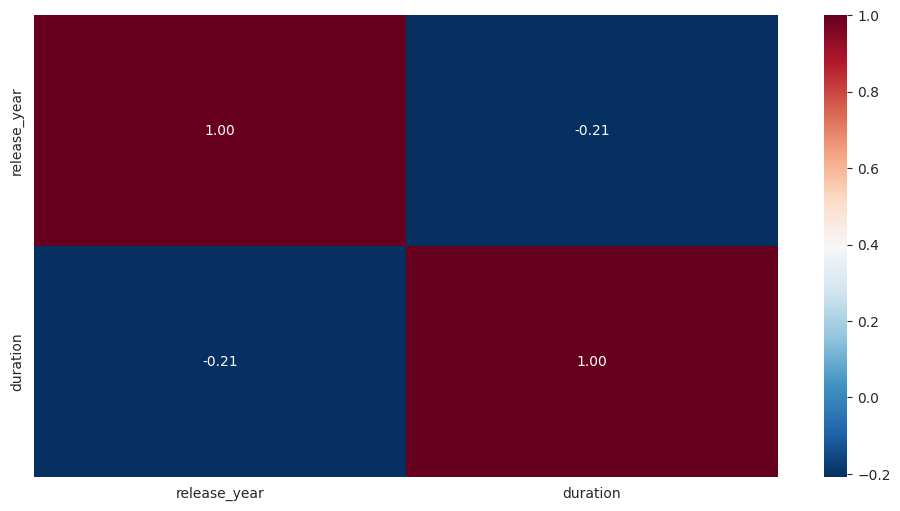

In [ ]:
# Correlation Matrix and Heatmap
df_numeric = df_clean.select_dtypes(include=['number'])

corr_matrix = df_numeric.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r')
plt.show()


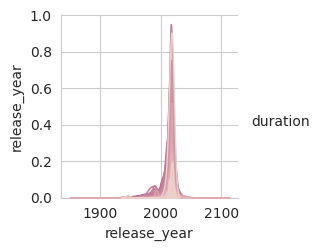

In [ ]:
df_numeric = df_numeric.sample(n=3000, random_state=6)
sns.pairplot(df_numeric, hue='duration', diag_kind='kde')
plt.show()

rating           G  NC-17         NR         PG       PG-13           R  \
type                                                                      
Movie    88.076923  146.0  95.443038  98.526316  107.774026  106.451515   
TV Show        NaN    NaN        NaN        NaN         NaN    1.000000   

rating        TV-14       TV-G      TV-MA      TV-PG       TV-Y      TV-Y7  \
type                                                                         
Movie    111.342147  81.509804  95.980974  95.466942  49.489130  64.437500   
TV Show    2.680851   1.250000   1.357895   1.714286   1.285714   1.888889   

rating   TV-Y7-FV     UR  
type                      
Movie        74.5  106.8  
TV Show       NaN    NaN  


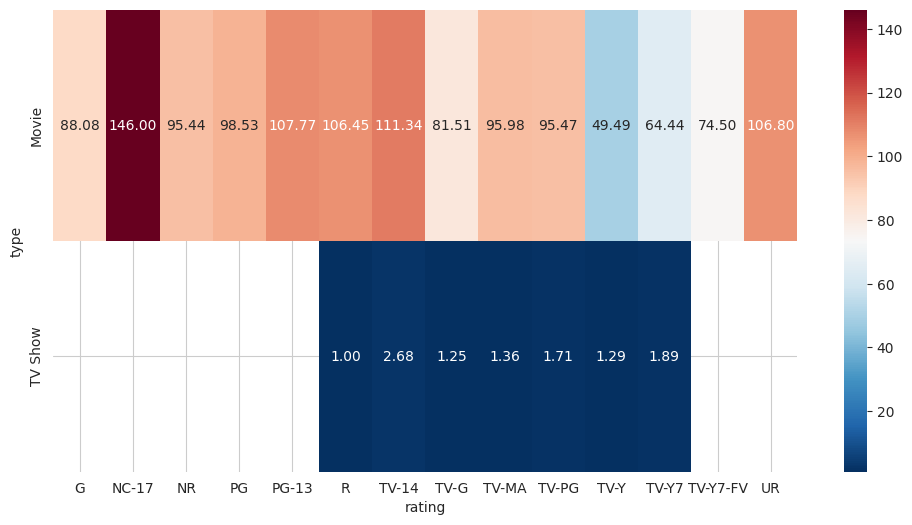

In [ ]:
#Pivot tables
pivot_table = pd.pivot_table(df_clean, values='duration', index='type', columns='rating', aggfunc='mean')
print(pivot_table)
df_pivot = pd.pivot_table(df_clean, values='duration', index='type', columns='rating', aggfunc='mean')
df_pivot = df_pivot.round(2)
sns.heatmap(df_pivot, annot=True, fmt='.2f', cmap='RdBu_r')
plt.show()

Pivot Table for Top 15 Titles by Average Duration:
rating                                                 G  NC-17     PG  PG-13  \
title                                                                           
A Bridge Too Far                                     NaN    NaN  176.0    NaN   
Aurora                                               NaN    NaN    NaN    NaN   
Blue Is the Warmest Color                            NaN  180.0    NaN    NaN   
Bye Bye London                                       NaN    NaN    NaN    NaN   
Dil Chahta Hai                                       NaN    NaN    NaN    NaN   
Dil Hai Tumhaara                                     NaN    NaN    NaN    NaN   
Doctor Zhivago                                       NaN    NaN    NaN  200.0   
Elephants Dream 4 Hour                               NaN    NaN    NaN    NaN   
Fiddler on the Roof                                181.0    NaN    NaN    NaN   
Fifty Year Old Teenager                              NaN  

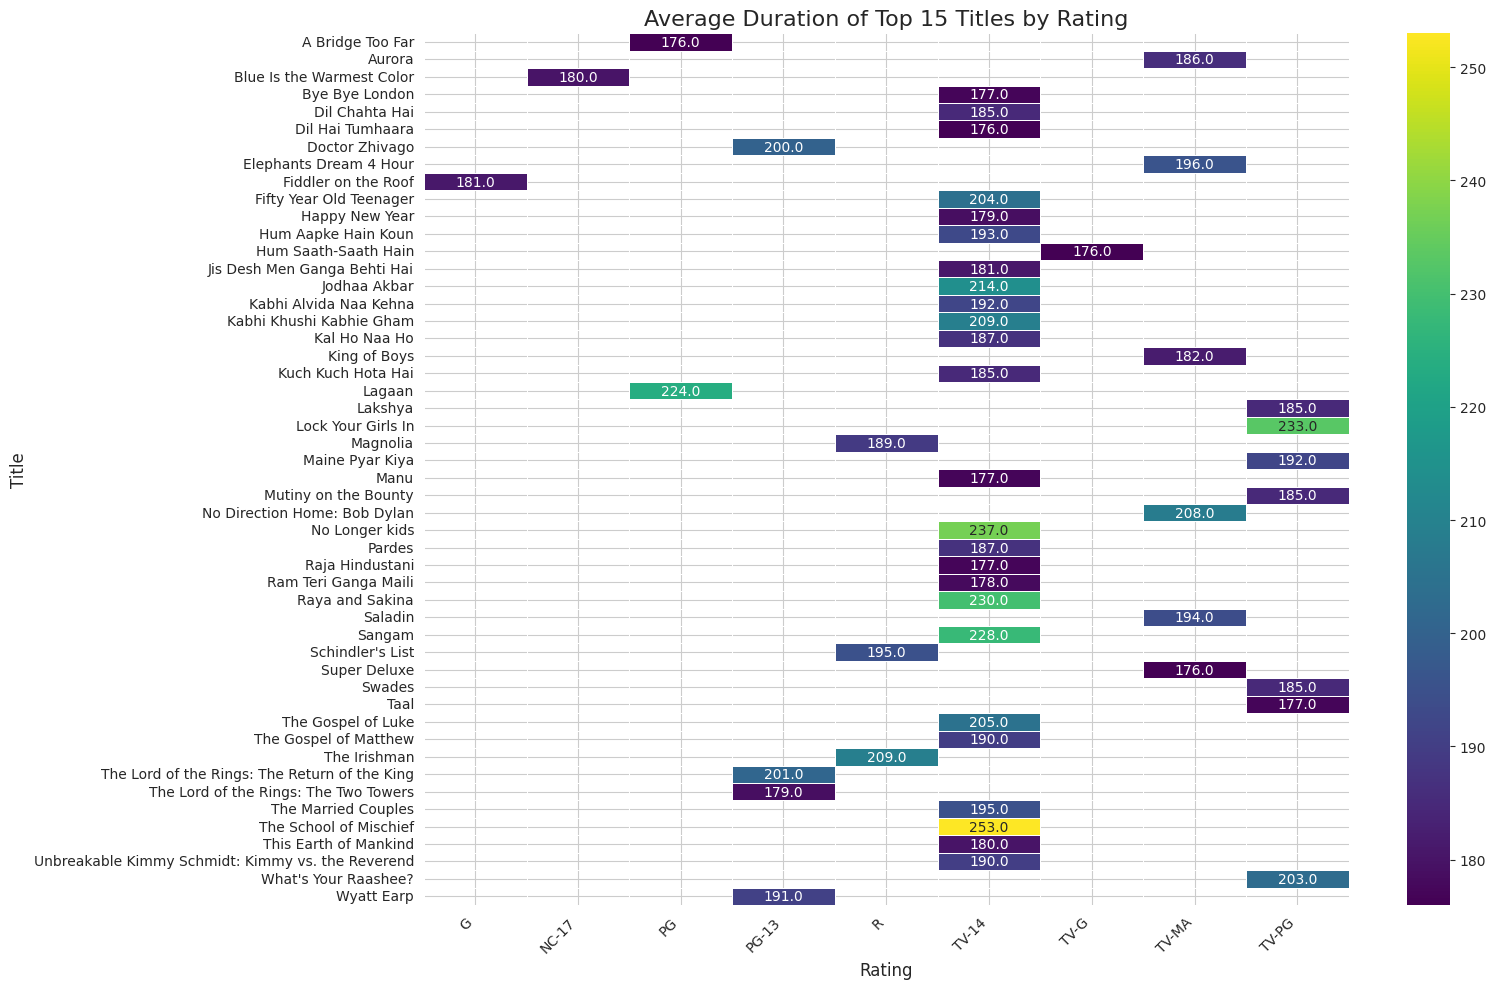

In [ ]:
# Pivot tables for Top 15 Titles by Average Duration

# Calculate average duration for each title
average_duration_per_title = df_clean.groupby('title')['duration'].mean()

# Get the top 15 titles based on average duration
top_15_titles = average_duration_per_title.nlargest(50).index.tolist()

# Filter df_clean to include only these top 15 titles
df_top_titles = df_clean[df_clean['title'].isin(top_15_titles)]

# Create a pivot table for these top titles
pivot_table = pd.pivot_table(df_top_titles, values='duration', index='title', columns='rating', aggfunc='mean')

print("Pivot Table for Top 15 Titles by Average Duration:")
print(pivot_table)

# Plotting the heatmap
df_pivot = pivot_table.round(2)
plt.figure(figsize=(16, 10)) # Adjust figure size for better readability
sns.heatmap(df_pivot, annot=True, fmt='.1f', cmap='viridis', linewidths=.5)
plt.title('Average Duration of Top 15 Titles by Rating', fontsize=16)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Title', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
unique_val_in_rating = df_clean['rating'].unique()
print(unique_val_in_rating)

['TV-MA' 'TV-PG' 'R' 'PG-13' 'TV-14' 'TV-G' 'PG' 'TV-Y7' 'NR' 'TV-Y' 'G'
 'TV-Y7-FV' 'UR' 'NC-17']


In [ ]:
df_clean['rating_score'] = df['rating'].map({
    'TV-MA': 1,
    'R': 2,
    'PG-13': 3,
    'PG': 4,
    'G': 5,
    'TV-14': 6,
    'TV-PG': 7,
    'NR': 8,
    'TV-G':15,
    'UR': 9,
    'NC-17': 10,
    'TV-Y7': 11,
    'TV-Y': 12,
    'TV-Y7-FV': 13,
    'G' : 14})
df_clean['box_office_collection'] = df_clean['duration']*10000 + df_clean['rating_score']*100000




<Axes: xlabel='rating_score'>

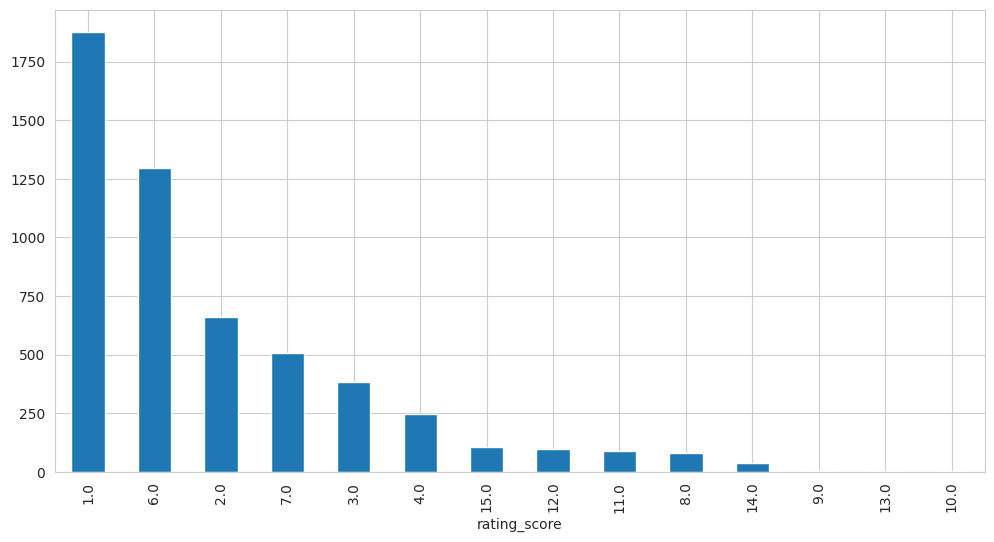

In [ ]:
df_clean['rating_score'].value_counts().plot(kind='bar')

In [ ]:
df_clean['box_office_collection']
df_clean['box_office_collection'].value_counts()
df_clean['box_office_collection'].value_counts(normalize=True)
df_clean.groupby('box_office_collection')['rating_score'].mean()

,rating_score
box_office_collection,
110000.0,1.0
120000.0,1.0
130000.0,1.0
140000.0,1.0
150000.0,1.0
...,...
2970000.0,6.0
3030000.0,7.0
3130000.0,6.0


In [ ]:
print(df_clean.shape)
df_clean.head()
df_clean['rating_score'].fillna(df_clean['rating_score'].mean(), inplace=True)
df_clean['box_office_collection'].fillna(df_clean['box_office_collection'].mean(), inplace=True)
print(df_clean.shape)

(5398, 14)
(5398, 14)


/tmp/ipykernel_12574/3293326475.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['rating_score'].fillna(df_clean['rating_score'].mean(), inplace=True)
/tmp/ipykernel_12574/3293326475.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].me

In [ ]:
df_clean.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


### Actionable Insights from Netflix Data Analysis

1.  **Content Acquisition Strategy for Directors:** A significant portion of content (nearly 30%) had 'Unknown' directors, which were subsequently removed. This suggests a potential gap in metadata collection. For future acquisitions or original productions, prioritize content with well-documented directorial information. Further analysis of the top directors' content and their associated ratings (as explored in 'director vs rating top 15' plot) can inform strategic partnerships and content commissioning.

2.  **Geographic Content Focus:** 'United States' and 'India' are the top content-producing countries. Deep dive into the specific genres and ratings that perform best in these regions. This insight can guide targeted content investments and marketing efforts to maximize audience engagement in these key markets.

3.  **Optimize Content Duration by Rating:** The 'duration vs rating' analysis revealed varying average durations across different content ratings. For instance, NC-17 movies tend to be longer, while TV-Y content is much shorter. This indicates an opportunity to tailor content length to specific target age groups/ratings, ensuring content aligns with audience expectations and consumption patterns.

4.  **Audience Segmentation based on Ratings:** The detailed breakdown of 'rating' shows diverse audience segments. Utilize the `rating_score` (derived from content ratings) in recommendation systems to personalize content suggestions, improving user experience and retention by matching content to individual rating preferences.

5.  **Address Metadata Gaps:** While missing values for 'director', 'cast', and 'country' were handled, the initial high percentage of missing values (especially for 'director') points to a need for improved data collection processes. Implementing stricter metadata requirements upon content ingestion can enhance data quality for future analyses.

6.  **Investigate Outlier Content:** Outliers in `release_year` and `duration` (e.g., very old releases, extremely long durations) were identified. These outliers might represent unique content with niche appeal or historical significance. Analyzing the performance and audience reception of these outliers could uncover opportunities for curated collections or specialized marketing.

7.  **Diversify Content Portfolio:** Analyze the 'type vs rating' relationships to identify any underrepresented combinations. For example, if certain ratings are heavily skewed towards 'Movie' but lack 'TV Show' content, it might indicate an opportunity to diversify the portfolio and attract a broader audience.

8.  **Leverage Synthetic Metrics for Content Value:** The created `box_office_collection` (derived from `duration` and `rating_score`) provides a hypothetical proxy for content value. In a real-world scenario, if actual box office data were available, this type of metric would be crucial for content valuation, investment decisions, and prioritizing content with higher revenue potential.

In [ ]:
### Summary of EDA Findings
'''
The Exploratory Data Analysis (EDA) of the Netflix dataset revealed several key characteristics and relationships:

**1. Data Overview and Quality:**
*   **Dataset Size:** The original dataset contained 7787 rows and 12 columns. After cleaning (specifically removing rows where 'director' was 'Unknown'), the dataset was reduced to 5398 rows.
*   **Missing Values:** Significant missing data was observed in 'director' (30.68%), 'cast' (9.22%), and 'country' (6.51%). Minor missing values were also present in 'date_added' and 'rating'. These were handled by filling text columns with 'Unknown', 'date_added' with its mean, and 'rating' with its mode.
*   **Duplicates:** No duplicate rows were found in the original dataset.
*   **Data Types:** 'release_year' and 'duration' were numerical (int64), while others like 'type', 'title', 'director', 'cast', 'country', 'rating', 'genres', and 'description' were object types. 'date_added' was converted to datetime.

**2. Univariate Analysis (Individual Column Distributions):**
*   **Duration:** The distribution of content duration is right-skewed, with a majority of content having shorter durations. Outliers were detected for both very short and very long durations using IQR and Z-score methods.
*   **Rating:** 'TV-MA', 'TV-14', and 'R' are the most frequent ratings. The dataset covers a wide range of ratings from 'G' to 'NC-17', 'TV-Y' to 'TV-MA'.
*   **Release Year:** The distribution of `release_year` shows a strong concentration of content released in more recent years (2010s and 2020s), with some older outliers present.
*   **Type:** The dataset is predominantly composed of 'Movie' type content, followed by 'TV Show'.

**3. Bivariate and Multivariate Analysis (Relationships between Columns):**
*   **Duration vs. Rating:** There's a noticeable variation in average content duration across different ratings. For example, 'NC-17' and 'PG-13' rated content tends to have longer durations on average, while 'TV-Y' and 'TV-G' content has significantly shorter durations. This implies a correlation between target audience (implied by rating) and content length.
*   **Country vs. Rating:** 'United States' and 'India' are the top content-producing countries. The distribution of ratings varies by country, suggesting different content strategies or audience preferences in different regions.
*   **Director vs. Rating:** Analyzing the top directors reveals their preferences or specializations in producing content for specific ratings. Some directors consistently produce high-rated content or content for mature audiences.
*   **Content Type vs. Duration:** Heatmaps show that 'Movies' occupy a wider range of duration bins, especially longer ones, compared to 'TV Shows', which are concentrated in shorter duration bins (representing episodes).
*   **Movie Duration vs. Rating (Heatmap):** This heatmap provides a detailed view of how different movie durations are distributed across various ratings, confirming that certain duration ranges are more common for specific ratings.
*   **Correlation Matrix:** `release_year` and `duration` show a slight negative correlation, meaning older content might generally be longer, or more recent content tends to be shorter (especially due to the rise of shorter TV show episodes).
*   **Derived Features:** `rating_score` was created to quantify ratings, and `box_office_collection` was created as a hypothetical metric combining duration and rating score, indicating a potential way to evaluate content 'value' if real financial data were available.

Overall, the EDA provided a strong foundation for understanding the Netflix content library, its composition, content quality, and potential areas for further strategic analysis, particularly regarding content acquisition, targeting diverse audiences, and improving metadata completeness.

'''

"\nThe Exploratory Data Analysis (EDA) of the Netflix dataset revealed several key characteristics and relationships:\n\n**1. Data Overview and Quality:**\n*   **Dataset Size:** The original dataset contained 7787 rows and 12 columns. After cleaning (specifically removing rows where 'director' was 'Unknown'), the dataset was reduced to 5398 rows.\n*   **Missing Values:** Significant missing data was observed in 'director' (30.68%), 'cast' (9.22%), and 'country' (6.51%). Minor missing values were also present in 'date_added' and 'rating'. These were handled by filling text columns with 'Unknown', 'date_added' with its mean, and 'rating' with its mode.\n*   **Duplicates:** No duplicate rows were found in the original dataset.\n*   **Data Types:** 'release_year' and 'duration' were numerical (int64), while others like 'type', 'title', 'director', 'cast', 'country', 'rating', 'genres', and 'description' were object types. 'date_added' was converted to datetime.\n\n**2. Univariate Analysis 